## Ejercicio 1
- Implementación del algoritmo genetico
- Optimización del algoritmo mediante optuna
- Comparación contra metodo basado en gradiente

In [75]:
import numpy as np

### Funciones objetivo

In [76]:
import numpy as np

def function_1(x, y):
    r2 = x**2 + y**2
    term1 = np.power(r2, 0.25)
    term2 = np.sin(50 * np.power(r2, 0.1))**2 + 1
    return term1 * term2

def function_2(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

### Codificacion

#### Codif

El proceso para la codificacion consta de:
- Real $\to$ Int
- Int $\to$ Gray

#### $Real \to Int$

Para la transformacion $Real \to Int$, primero normalizaremos los valores, mediante $$\frac{x -L}{U-L}$$ Luego, lo multiplicamos por el numero de representaciones disponibles (Usamos 32 bits para cada cromosoma, ya que supera para ambas funciones un $\epsilon < 10^{-6}$, y es la siguiente potencia de 2 en el exponente luego de 16, que no logra superar un error de $10^{-3}$ en la codificacion).
$$ \frac{x -L}{U-L} * (2^{32} -1)$$Finalmente, realizamos la operacion $int()$ aplicando aqui el error en la codificacion (Ej. Si quedan 2 valores, que dan como resultado 225.1, y 225.6, seran representados con el mismo cromosoma). Por lo que la primera tranformación sera $$ int\left(\frac{x -L}{U-L} * (2^{32} -1)\right)$$


In [77]:
def real_to_int(x, L, U, n_bits):
    x = np.clip(x, L, U) #me aseguro que pertenezca al dominio
    return int(((x - L) / (U - L)) * (2**n_bits - 1))


In [78]:
#Ej
bits =32
val = 55
entero = real_to_int(val,-100,100,bits)
print(entero)

3328599653


#### $Int \to Gray$

Para realizar esta conversión, se usa una formula $$G = B \oplus (B \gg 1)$$ Esto es, hacer un xor bit a bit, entre el binario original, y su version desplazada un bit

In [79]:
def int_to_gray(n):
    return n ^ (n >> 1)

In [80]:
#Ej
bits =32
val = 55
entero = real_to_int(val,-100,100,bits)
print(entero)
print(bin(entero))
gray = int_to_gray(entero)
print(gray)
print(bin(gray))

3328599653
0b11000110011001100110011001100101
2773833047
0b10100101010101010101010101010111


#### Decodificación

Luego de la evaluación de nuestro algoritmo, debemos decodificar y volver al conjunto real, para poder verificar el fitness que nos da.

- Para pasar de Gray a Int, debemos de realizar una operación en "cascada", por ejemplo:
Si tengo en Gray $0110$, tengo que hacer lo siguiente:
- Dejo el MSB, que sera el MSB tambien en la representación entera.
- Luego, hago un XOR entre el bit 2 de Gray, y el bit 3 en el binario (El MSB), $0 \oplus 1 = 1$, que sera el bit 2 del binario
- Luego, hago un xor entre el bit 1 de Gray, y el 2 del binario, $1 \oplus 1 = 0$, que sera el bit 1 del binario.
- Finalmente, hago un xor entre el bit 0 de Gray, y el 1 del binario, $0 \oplus 0 = 0$, que sera el bit 0 del binario.
Quedandonos $0100$

En vez de hacer esto bit a bit, se usa el siguiente algoritmo por eficiencia (XOR accumulation)

In [81]:
def gray_to_int(n):
    mask = n
    while mask > 0:
        mask >>= 1
        n ^= mask
    return n

Su version vectorizada (muuucho mas rapido)

In [82]:
def gray_to_int_vec(n):
        res = n.copy()
        while np.any(n > 0):
            n >>= 1
            res ^= n
        return res

Y para pasar de Int a Real, despejamos X de nuestra formula para pasar de Real a Int

In [83]:
def int_to_real(idx, L, U, n_bits):
    return L + idx * (U - L) / (2**n_bits - 1) #idx es el indice en la grilla de las representaciones posibles en binario

### Seleccion de poblacion

Para realizar la selección de los individuos, tomo muestras de ventanas de distintos tamaños: $$Window Size = int\left( popsize * (1- \frac{i}{popsize}) \right)$$ Esta ecuación, hace que, a medida que avanza el contador de i, la ventana se acomoda de manera dinamica. $ 1- \frac{i}{popsize}$ nos acomoda el porcentaje de la población de la cual quiero muestrea (i = 0 es toda la poblacion, i = popsize - 1 nos tomas solo el mejor)

In [84]:
def selection_windows(pop_size, fitness, population):
        idx_sorted = np.argsort(fitness) # Ordenar de mejor a peor
        selected_indices = []
        
        for i in range(pop_size):
            window_size = int(pop_size * (1 - (i / pop_size)))
            limit = max(1, window_size)
            
            pick = np.random.randint(0, limit)
            selected_indices.append(idx_sorted[pick])
            
        return population[selected_indices]

Por otro lado, realizamos la implementación que se utiliza para la demostración del teorema de esquemas.

El teorema de esquemas nos dice que el número esperado de ejemplares de un esquema $H$ en la generación siguiente es:$$E[m(H, t+1)] = m(H, t) \frac{f(H)}{\bar{f}}$$Para que esta igualdad se mantenga en la práctica, la probabilidad de que un individuo $i$ sea seleccionado ($p_i$) debe ser:$$p_i = \frac{f_i}{\sum_{j=1}^{N} f_j}$$ (Es la unica manera de que la seleccion sea funcion lineal de la aptitud, con otros puedo castigar demasiado)

In [85]:
def selection_proportional(n_pop, fitness, population):
    #selección por ruleta (Fitness Proportional Selection) 
    # El individuo con el fitness más alto (peor) debe tener la probabilidad más baja.
    f_max = np.max(fitness)
    f_min = np.min(fitness)
    
    # f_trans = (Peor_Fitness - Fitness_i) + Offset
    # El offset evita que el peor individuo tenga probabilidad 0 absoluta,
    f_trans = (f_max - fitness) + (f_max - f_min) * 0.05 + 1e-9
    
    # calculo de probabilidades según el Teorema de Esquemas
    # p_i = f_i / sum(f)
    total_fitness = np.sum(f_trans)
    probs = f_trans / total_fitness
    
    # muestreo segun probabilidades
    indices = np.arange(len(population))
    selected_indices = np.random.choice(indices, size=n_pop, p=probs)
    
    return population[selected_indices]

#### Cruza, mutación y reemplazo

Para la cruza, vamos a usar la cruza de 2 puntos (Cortamos una parte intermedia de un cromosoma de un padre, y la intercambiamos con la del otro padre)

In [86]:
def crossover_2point(p1, p2, pc, chromosome_bits = 32):
        if np.random.rand() < pc:
            points_x = sorted(np.random.choice(range(chromosome_bits), 2, replace=False))
            points_y = [points_x[0] +chromosome_bits, points_x[1] +chromosome_bits]
            c1_x = np.concatenate([p1[:points_x[0]], p2[points_x[0]:points_x[1]], p1[points_x[1]:chromosome_bits]])
            c2_x = np.concatenate([p2[:points_x[0]], p1[points_x[0]:points_x[1]], p2[points_x[1]:chromosome_bits]])
            c1_y = np.concatenate([p1[chromosome_bits:points_y[0]], p2[points_y[0]:points_y[1]], p1[points_y[1]:]])
            c2_y = np.concatenate([p2[chromosome_bits:points_y[0]], p1[points_y[0]:points_y[1]], p2[points_y[1]:]])
            c1 = np.concatenate([c1_x,c1_y])
            c2 = np.concatenate([c2_x,c2_y])
            return c1, c2
        return p1.copy(), p2.copy()

Para la mutación, dada una probabilidad, vamos a hacer un flip de la mutación

In [87]:
def mutate(individual, pm, total_bits=64):
    if np.random.rand() < pm:
        # Selecciona un índice aleatorio en todo el largo del cromosoma (x + y)
        idx = np.random.randint(0, total_bits)
        
        # Flip del bit: 0 -> 1 o 1 -> 0
        individual[idx] = 1 - individual[idx]
        
    return individual

In [88]:
def get_elites(population, fitness, n_elites):
    """
    Extrae los n mejores individuos de la población.
    """
    # Obtenemos los índices que ordenarían el fitness de mayor a menor
    elite_indices = np.argsort(fitness)[:n_elites]
    return population[elite_indices].copy()

### Algoritmo y evaluacion

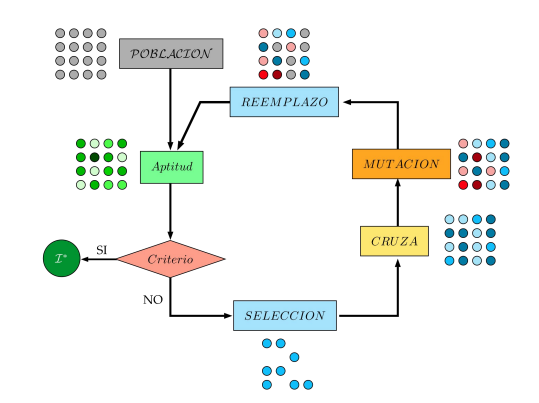

In [89]:
def evaluar_fitness(individual, L, U, funcion_objetivo,n_bits_per_var):   
    # 2. Separar el cromosoma en x e y
    # El individuo es un array de bits de tamaño 64
    bits_x = individual[:n_bits_per_var]
    bits_y = individual[n_bits_per_var:]
    # Convertir arrays de bits a un solo entero decimal (en formato Gray)
    # necesito que las operaciones bit a bit (>>, ^) funcionen
    int_gray_x = int("".join(bits_x.astype(str)), 2)
    int_gray_y = int("".join(bits_y.astype(str)), 2)
    
    idx_x = gray_to_int(int_gray_x)
    idx_y = gray_to_int(int_gray_y)
    
    x_real = int_to_real(idx_x, L, U, n_bits_per_var)
    y_real = int_to_real(idx_y, L, U, n_bits_per_var)
    
    return funcion_objetivo(x_real, y_real)

El tema de hacer esto con un string hace cuello de botella, voy a terminar usando esto.

In [90]:
def evaluar_fitness_vec(population, L, U,funcion_objetivo, n_bits_per_var):
    # population es (tamano_muestra, 64)
    n_bits = n_bits_per_var
    
    # Convertir bits a enteros usando potencias de 2 (esto me soluciona el cuello de botella, paso directamente)
    powers = 2 ** np.arange(n_bits)[::-1]
    
    # Separar x e y
    gray_x = population[:, :n_bits].dot(powers)
    gray_y = population[:, n_bits:].dot(powers)

    idx_x = gray_to_int_vec(gray_x)
    idx_y = gray_to_int_vec(gray_y)
    
    # Escalar a real
    x_real = L + idx_x * (U - L) / (2**n_bits - 1) #no llamo a la funcion
    y_real = L + idx_y * (U - L) / (2**n_bits - 1)
    
    return funcion_objetivo(x_real, y_real)

In [91]:
def run_evolution(poblacion_inicial, tamano_muestra ,select_method, n_gen, n_bits, pc, pm, n_elites, L, U, funcion_objetivo):

    initial_n = poblacion_inicial
    massive_pop = np.random.randint(0, 2, (initial_n, n_bits))
    fitness_massive = np.array([evaluar_fitness(ind, L, U, funcion_objetivo,n_bits//2) for ind in massive_pop])
    population = select_method(tamano_muestra, fitness_massive, massive_pop)
    history = []
    for gen in range(n_gen):
        # 1. Evaluar a todos
        fitness = np.array([evaluar_fitness(ind, L, U, funcion_objetivo,n_bits//2) for ind in population])
        mejor_fitness_actual = np.min(fitness)
        history.append(mejor_fitness_actual)
        # 2. Elitismo: Guardar a los mejores directamente
        new_population = []
        elites = get_elites(population, fitness, n_elites)
        new_population.extend(elites)
        
        # Genero el "mating pool"
        # Esta es la clave: generamos los tamano_muestra padres aquí
        mating_pool = select_method(tamano_muestra, fitness, population)
        
        # 4. Cruce y Mutación
        # Usamos los padres del pool para crear los hijos que faltan
        idx_padre = 0
        while len(new_population) < tamano_muestra:
            # Tomamos dos padres del pool
            p1 = mating_pool[idx_padre % tamano_muestra]
            p2 = mating_pool[(idx_padre + 1) % tamano_muestra]
            
            # Cruce (n_bits // 2 porque el individuo tiene x e y)
            c1, c2 = crossover_2point(p1, p2, pc, n_bits // 2)
            
            # Mutación de un bit y guardado
            new_population.append(mutate(c1, pm, n_bits))
            if len(new_population) < tamano_muestra:
                new_population.append(mutate(c2, pm, n_bits))
            
            idx_padre += 2
        
        # 5. Reemplazo total de la población
        population = np.array(new_population)
        
        if gen % 10 == 0:
            print(f"Gen {gen} | Mejor Fitness: {np.min(fitness):.6f}")

    return population, history

En su version vectorizada

In [112]:
def run_evolution_vec(poblacion_inicial, tamano_muestra ,select_method, n_gen, n_bits, pc, pm, n_elites, L, U, funcion_objetivo):

    initial_n = poblacion_inicial
    massive_pop = np.random.randint(0, 2, (initial_n, n_bits))
    fitness_massive = evaluar_fitness_vec(massive_pop, L, U, funcion_objetivo,n_bits//2)
    population = select_method(tamano_muestra, fitness_massive, massive_pop)
    history = []
    for gen in range(n_gen):
        # 1. Evaluar a todos
        fitness = evaluar_fitness_vec(population, L, U,funcion_objetivo, n_bits//2)
        # Guardamos el mejor fitness encontrado en esta generación
        mejor_fitness_actual = np.min(fitness)
        history.append(mejor_fitness_actual)
        
        # 2. Elitismo: Guardar a los mejores directamente
        new_population = []
        elites = get_elites(population, fitness, n_elites)
        new_population.extend(elites)
        
        # Genero el "mating pool"
        # Esta es la clave: generamos los tamano_muestra padres aquí
        mating_pool = select_method(tamano_muestra, fitness, population)
        
        # 4. Cruce y Mutación
        # Usamos los padres del pool para crear los hijos que faltan
        idx_padre = 0
        while len(new_population) < tamano_muestra:
            # Tomamos dos padres del pool
            p1 = mating_pool[idx_padre % tamano_muestra]
            p2 = mating_pool[(idx_padre + 1) % tamano_muestra]
            
            # Cruce (n_bits // 2 porque el individuo tiene x e y)
            c1, c2 = crossover_2point(p1, p2, pc, n_bits // 2)
            
            # Mutación de un bit y guardado
            new_population.append(mutate(c1, pm, n_bits))
            if len(new_population) < tamano_muestra:
                new_population.append(mutate(c2, pm, n_bits))
            
            idx_padre += 2
        
        # 5. Reemplazo total de la población
        population = np.array(new_population)
        
        if gen % 10 == 0:
            print(f"Gen {gen} | Mejor Fitness: {np.min(fitness):.6f}")

    return population, history

In [113]:
# Parámetros
poblacion_inicial = 10000
muestra_poblacion = 500
generaciones = 100
total_bits = 64 # 32 para x + 32 para y
prob_cruce = 0.8
prob_mutacion = 0.01 # Probabilidad por individuo
elites_por_gen = 2
L =-100
U=100
funcion_objetivo = function_2

# Ejecución
poblacion_final = run_evolution_vec(
    poblacion_inicial=poblacion_inicial,
    tamano_muestra=muestra_poblacion, 
    select_method=selection_proportional,
    n_gen=generaciones, 
    n_bits=total_bits, 
    pc=prob_cruce, 
    pm=prob_mutacion, 
    n_elites=elites_por_gen,
    L=L,
    U=U,
    funcion_objetivo=funcion_objetivo
)

Gen 0 | Mejor Fitness: 104.376094
Gen 10 | Mejor Fitness: 37.513963
Gen 20 | Mejor Fitness: 12.881291
Gen 30 | Mejor Fitness: 4.380943
Gen 40 | Mejor Fitness: 0.462044
Gen 50 | Mejor Fitness: 0.004889
Gen 60 | Mejor Fitness: 0.004868
Gen 70 | Mejor Fitness: 0.004596
Gen 80 | Mejor Fitness: 0.004422
Gen 90 | Mejor Fitness: 0.004411


### Estudio de Hiperparámetros

In [114]:
import numpy as np

def run_evolution_study_vec(poblacion_inicial, tamano_muestra, select_method, n_gen, n_bits, pc, pm, n_elites, L, U, funcion_objetivo):
    """
    Versión para análisis de hiperparámetros basada en la lógica de población masiva inicial.
    Devuelve: (mejor_fitness_global, generacion_en_que_se_encontro)
    """
    # 1. Inicialización Masiva y Selección de Muestra Inicial
    massive_pop = np.random.randint(0, 2, (poblacion_inicial, n_bits))
    fitness_massive = evaluar_fitness_vec(massive_pop, L, U, funcion_objetivo, n_bits // 2)
    population = select_method(tamano_muestra, fitness_massive, massive_pop)

    best_fitness_overall = np.inf
    best_gen = 0
    
    for gen in range(n_gen):
        # 2. Evaluación Vectorizada (más eficiente que bucles for)
        fitness = evaluar_fitness_vec(population, L, U, funcion_objetivo, n_bits // 2)
        
        # 3. Seguimiento del mejor global
        indice_mejor_actual = np.argmin(fitness)
        mejor_fitness_gen = fitness[indice_mejor_actual]
        
        if mejor_fitness_gen < best_fitness_overall:
            best_fitness_overall = mejor_fitness_gen
            best_gen = gen

        # 4. Elitismo
        new_population = []
        if n_elites > 0:
            elites = get_elites(population, fitness, n_elites)
            new_population.extend(elites)

        # 5. Mating Pool
        mating_pool = select_method(tamano_muestra, fitness, population)

        # 6. Reproducción (Cruce y Mutación)
        idx_padre = 0
        while len(new_population) < tamano_muestra:
            p1 = mating_pool[idx_padre % tamano_muestra]
            p2 = mating_pool[(idx_padre + 1) % tamano_muestra]
            
            # Cruce de 2 puntos
            c1, c2 = crossover_2point(p1, p2, pc, n_bits // 2)
            
            # Mutación y agregado
            new_population.append(mutate(c1, pm, n_bits))
            if len(new_population) < tamano_muestra:
                new_population.append(mutate(c2, pm, n_bits))
            
            idx_padre += 2

        # 7. Actualización de población
        population = np.array(new_population)

    return best_fitness_overall, best_gen

In [115]:
def study_hyperparameter(param_name, param_values, defaults, n_iters=25):
    results = {}
    for val in param_values:
        params = defaults.copy()
        params[param_name] = val

        fitnesses = []
        best_gens = []

        # Formateo de nombre para métodos de selección o valores numéricos
        val_display = val.__name__ if callable(val) else str(val)

        for _ in range(n_iters):
            fit, gen = run_evolution_study_vec(
                poblacion_inicial=params['poblacion_inicial'],
                tamano_muestra=params['tamano_muestra'],
                select_method=params['select_method'],
                n_gen=params['generaciones'],
                n_bits=params['total_bits'],
                pc=params['prob_cruce'],
                pm=params['prob_mutacion'],
                n_elites=params['elites_por_gen'],
                L=params['L'],
                U=params['U'],
                funcion_objetivo=params['funcion_objetivo']
            )
            fitnesses.append(fit)
            best_gens.append(gen)

        results[val] = {
            'fitness_medio':      np.mean(fitnesses),
            'fitness_mediano':    np.median(fitnesses),
            'gen_mejor_media':    np.mean(best_gens),
            'gen_mejor_mediana':  np.median(best_gens),
        }
        
        print(f"  {param_name}={val_display:>20} | "
              f"fit_medio={results[val]['fitness_medio']:.4f}  "
              f"fit_median={results[val]['fitness_mediano']:.4f}  "
              f"gen_media={results[val]['gen_mejor_media']:.1f}")

    return results

In [116]:
RANGOS = {
    'select_method':     [selection_windows, selection_proportional],
    'generaciones':      [10, 25, 50, 100, 200],
    'prob_cruce':        [0.45, 0.5,0.6, 0.7,0.8, 0.9,0.95, 1.0],
    'prob_mutacion':     [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5],
    'elites_por_gen':    [0, 1, 2, 5, 10],
    'total_bits':        [32, 48, 64, 96, 128],
    'tamano_muestra':    [100, 200,400,500,750,900,1000]
}

# La población inicial se mantiene fija aquí para que run_evolution_study_vec pueda operar
DEFAULTS_ESTUDIO = {
    'poblacion_inicial': 20000,     # Valor fijo para el pool masivo inicial
    'tamano_muestra':    200,    
    'select_method':     selection_windows, 
    'generaciones':      50,
    'total_bits':        64,
    'prob_cruce':        0.8,
    'prob_mutacion':     0.01,
    'elites_por_gen':    2,
    'L':                 -2048,
    'U':                 2048,
    'funcion_objetivo':  function_2,
}

In [117]:
import time

# Ejecución del Loop de Estudio
all_results = {}
t_total = time.time()

for param_name, param_values in RANGOS.items():
    print(f"\n{'─'*80}")
    print(f"ANALIZANDO: {param_name}")
    print(f"{'─'*80}")
    all_results[param_name] = study_hyperparameter(param_name, param_values, DEFAULTS_ESTUDIO, n_iters=10)


────────────────────────────────────────────────────────────────────────────────
ANALIZANDO: select_method
────────────────────────────────────────────────────────────────────────────────
  select_method=   selection_windows | fit_medio=250.6526  fit_median=147.2755  gen_media=45.2
  select_method=selection_proportional | fit_medio=747.9737  fit_median=786.5651  gen_media=44.9

────────────────────────────────────────────────────────────────────────────────
ANALIZANDO: generaciones
────────────────────────────────────────────────────────────────────────────────
  generaciones=                  10 | fit_medio=112.2864  fit_median=26.4155  gen_media=8.7
  generaciones=                  25 | fit_medio=218.6537  fit_median=57.3584  gen_media=21.8
  generaciones=                  50 | fit_medio=303.7785  fit_median=46.6984  gen_media=46.7
  generaciones=                 100 | fit_medio=262.1247  fit_median=193.6668  gen_media=94.6
  generaciones=                 200 | fit_medio=136.0378  f

In [118]:
import pandas as pd

for param_name, results in all_results.items():
    print(f"\n{'═'*70}")
    print(f"  Hiperparámetro: {param_name}")
    print(f"{'═'*70}")
    rows = []
    for val, stats in results.items():
        rows.append({
            param_name:              val,
            'Fitness Medio':         round(stats['fitness_medio'],        6),
            'Fitness Mediano':       round(stats['fitness_mediano'],      6),
            'Gen. Mejor (Media)':    round(stats['gen_mejor_media'],      2),
            'Gen. Mejor (Mediana)':  round(stats['gen_mejor_mediana'],    1),
        })
    df = pd.DataFrame(rows).set_index(param_name)
    print(df.to_string())


══════════════════════════════════════════════════════════════════════
  Hiperparámetro: select_method
══════════════════════════════════════════════════════════════════════
                                                         Fitness Medio  Fitness Mediano  Gen. Mejor (Media)  Gen. Mejor (Mediana)
select_method                                                                                                                    
<function selection_windows at 0x0000028A54E24C20>          250.652579       147.275513                45.2                  46.0
<function selection_proportional at 0x0000028A54C94360>     747.973679       786.565060                44.9                  47.0

══════════════════════════════════════════════════════════════════════
  Hiperparámetro: generaciones
══════════════════════════════════════════════════════════════════════
              Fitness Medio  Fitness Mediano  Gen. Mejor (Media)  Gen. Mejor (Mediana)
generaciones                                

### Comparacion contra Metodo de gradiente

In [119]:
import optuna

def objective(trial):
    # Sugerencias dinámicas de parámetros
    pc = trial.suggest_float("pc", 0.6, 0.95)
    pm = trial.suggest_float("pm", 0.001, 0.05, log=True)
    n_elites = trial.suggest_int("n_elites", 1, 5)
    metodo = trial.suggest_categorical("metodo", ["proportional", "windows"])
    tamano_muestra= trial.suggest_int("tamano_muestra",100,1000)
    
    sel_func = selection_proportional if metodo == "proportional" else selection_windows

    # Ejecutamos 5 réplicas para reducir el ruido estadístico
    replicas = 5
    final_scores = []
    for _ in range(replicas):
        _, history = run_evolution_vec(
            poblacion_inicial=20000, tamano_muestra=tamano_muestra, select_method=sel_func,
            n_gen=80, n_bits=64, pc=pc, pm=pm, n_elites=n_elites, 
            L=-2048, U=2048, funcion_objetivo=function_2
        )
        final_scores.append(history[-1])
    
    return np.mean(final_scores)

# Ejecutar la optimización
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50) # Prueba 100 combinaciones

[I 2026-05-13 02:29:20,500] A new study created in memory with name: no-name-62e46c1b-4e60-4ccc-b67b-76a6a6e97545


Gen 0 | Mejor Fitness: 3207.755099
Gen 10 | Mejor Fitness: 34.939690
Gen 20 | Mejor Fitness: 34.735089
Gen 30 | Mejor Fitness: 34.735006
Gen 40 | Mejor Fitness: 34.735006
Gen 50 | Mejor Fitness: 34.734999
Gen 60 | Mejor Fitness: 34.734999
Gen 70 | Mejor Fitness: 34.734998
Gen 0 | Mejor Fitness: 5808.357142
Gen 10 | Mejor Fitness: 32.086420
Gen 20 | Mejor Fitness: 32.084243
Gen 30 | Mejor Fitness: 32.083993
Gen 40 | Mejor Fitness: 32.083492
Gen 50 | Mejor Fitness: 32.083492
Gen 60 | Mejor Fitness: 32.083484
Gen 70 | Mejor Fitness: 32.083484
Gen 0 | Mejor Fitness: 1214.837010
Gen 10 | Mejor Fitness: 618.713588
Gen 20 | Mejor Fitness: 586.422482
Gen 30 | Mejor Fitness: 455.770718
Gen 40 | Mejor Fitness: 455.362640
Gen 50 | Mejor Fitness: 455.361035
Gen 60 | Mejor Fitness: 455.337292
Gen 70 | Mejor Fitness: 452.178511
Gen 0 | Mejor Fitness: 8239.265317
Gen 10 | Mejor Fitness: 14.121981
Gen 20 | Mejor Fitness: 14.072889
Gen 30 | Mejor Fitness: 14.063178
Gen 40 | Mejor Fitness: 14.063178
Gen

[I 2026-05-13 02:29:25,051] Trial 0 finished with value: 110.44617625108481 and parameters: {'pc': 0.7263166316365827, 'pm': 0.0014863847426449478, 'n_elites': 3, 'metodo': 'windows', 'tamano_muestra': 743}. Best is trial 0 with value: 110.44617625108481.


Gen 0 | Mejor Fitness: 258772.837008
Gen 10 | Mejor Fitness: 5151.766849
Gen 20 | Mejor Fitness: 1153.387800
Gen 30 | Mejor Fitness: 1151.572640
Gen 40 | Mejor Fitness: 1151.292510
Gen 50 | Mejor Fitness: 21.650400
Gen 60 | Mejor Fitness: 10.346075
Gen 70 | Mejor Fitness: 2.315205
Gen 0 | Mejor Fitness: 51864240.315131
Gen 10 | Mejor Fitness: 46043.378155
Gen 20 | Mejor Fitness: 1683.092045
Gen 30 | Mejor Fitness: 963.914456
Gen 40 | Mejor Fitness: 833.429506
Gen 50 | Mejor Fitness: 832.338698
Gen 60 | Mejor Fitness: 832.338698
Gen 70 | Mejor Fitness: 832.321418
Gen 0 | Mejor Fitness: 10822445.305648
Gen 10 | Mejor Fitness: 1955.933632
Gen 20 | Mejor Fitness: 493.167440
Gen 30 | Mejor Fitness: 278.508251
Gen 40 | Mejor Fitness: 278.336654
Gen 50 | Mejor Fitness: 278.292082
Gen 60 | Mejor Fitness: 278.291847
Gen 70 | Mejor Fitness: 277.998489
Gen 0 | Mejor Fitness: 1508035.907211
Gen 10 | Mejor Fitness: 10751.554522
Gen 20 | Mejor Fitness: 1260.386061
Gen 30 | Mejor Fitness: 1223.703188

[I 2026-05-13 02:29:26,890] Trial 1 finished with value: 537.4056856842412 and parameters: {'pc': 0.7571144984979512, 'pm': 0.003350687223808103, 'n_elites': 3, 'metodo': 'proportional', 'tamano_muestra': 329}. Best is trial 0 with value: 110.44617625108481.


...

[I 2026-05-13 02:33:02,008] Trial 47 finished with value: 63.1325427981674 and parameters: {'pc': 0.8888649591889002, 'pm': 0.03242960649769198, 'n_elites': 3, 'metodo': 'windows', 'tamano_muestra': 844}. Best is trial 13 with value: 2.910492463653354.


Gen 70 | Mejor Fitness: 5.817209
Gen 0 | Mejor Fitness: 53.867375
Gen 10 | Mejor Fitness: 8.022484
Gen 20 | Mejor Fitness: 8.016955
Gen 30 | Mejor Fitness: 8.016938
Gen 40 | Mejor Fitness: 8.015959
Gen 50 | Mejor Fitness: 8.015952
Gen 60 | Mejor Fitness: 8.015781
Gen 70 | Mejor Fitness: 8.015764
Gen 0 | Mejor Fitness: 1220.727219
Gen 10 | Mejor Fitness: 129.139136
Gen 20 | Mejor Fitness: 128.975947
Gen 30 | Mejor Fitness: 128.975613
Gen 40 | Mejor Fitness: 128.974919
Gen 50 | Mejor Fitness: 128.974878
Gen 60 | Mejor Fitness: 128.974240
Gen 70 | Mejor Fitness: 128.974234
Gen 0 | Mejor Fitness: 4590.498920
Gen 10 | Mejor Fitness: 0.009867
Gen 20 | Mejor Fitness: 0.008488
Gen 30 | Mejor Fitness: 0.008488
Gen 40 | Mejor Fitness: 0.008488
Gen 50 | Mejor Fitness: 0.008464
Gen 60 | Mejor Fitness: 0.008463
Gen 70 | Mejor Fitness: 0.008463
Gen 0 | Mejor Fitness: 3563.729676
Gen 10 | Mejor Fitness: 77.260079
Gen 20 | Mejor Fitness: 74.393714
Gen 30 | Mejor Fitness: 74.388435
Gen 40 | Mejor Fitne

[I 2026-05-13 02:33:07,326] Trial 48 finished with value: 42.21433440281657 and parameters: {'pc': 0.7035656688473325, 'pm': 0.0012729490892974286, 'n_elites': 5, 'metodo': 'windows', 'tamano_muestra': 955}. Best is trial 13 with value: 2.910492463653354.


Gen 70 | Mejor Fitness: 1.733568
Gen 0 | Mejor Fitness: 7848.987237
Gen 10 | Mejor Fitness: 26.961521
Gen 20 | Mejor Fitness: 26.950901
Gen 30 | Mejor Fitness: 26.948558
Gen 40 | Mejor Fitness: 26.942844
Gen 50 | Mejor Fitness: 26.940311
Gen 60 | Mejor Fitness: 26.938031
Gen 70 | Mejor Fitness: 26.932961
Gen 0 | Mejor Fitness: 847.643207
Gen 10 | Mejor Fitness: 30.464445
Gen 20 | Mejor Fitness: 30.453215
Gen 30 | Mejor Fitness: 30.449831
Gen 40 | Mejor Fitness: 30.448730
Gen 50 | Mejor Fitness: 30.446886
Gen 60 | Mejor Fitness: 30.441416
Gen 70 | Mejor Fitness: 30.436362
Gen 0 | Mejor Fitness: 406.305571
Gen 10 | Mejor Fitness: 13.374397
Gen 20 | Mejor Fitness: 13.331412
Gen 30 | Mejor Fitness: 13.325863
Gen 40 | Mejor Fitness: 13.323127
Gen 50 | Mejor Fitness: 13.320016
Gen 60 | Mejor Fitness: 13.316057
Gen 70 | Mejor Fitness: 13.313919
Gen 0 | Mejor Fitness: 1431.842783
Gen 10 | Mejor Fitness: 64.960973
Gen 20 | Mejor Fitness: 64.908676
Gen 30 | Mejor Fitness: 64.897659
Gen 40 | Mejo

[I 2026-05-13 02:33:13,925] Trial 49 finished with value: 33.33494133893701 and parameters: {'pc': 0.948749291161532, 'pm': 0.04703793594734807, 'n_elites': 4, 'metodo': 'windows', 'tamano_muestra': 896}. Best is trial 13 with value: 2.910492463653354.


In [120]:
# El mejor conjunto de hiperparámetros encontrados
best_params = study.best_params
print(f"Mejores parámetros: {best_params}")

# El valor de la función objetivo para esos parámetros
print(f"Mejor fitness medio: {study.best_value}")

# Acceder a un parámetro específico
pc_optimo = study.best_params['pc']

Mejores parámetros: {'pc': 0.8121853019838787, 'pm': 0.013706337605577868, 'n_elites': 4, 'metodo': 'windows', 'tamano_muestra': 937}
Mejor fitness medio: 2.910492463653354


In [121]:
df_results = study.trials_dataframe()
df_results.to_csv("optuna_results.csv", index=False)

In [123]:
from scipy.optimize import minimize
import numpy as np

# Definimos el wrapper para que Scipy pueda hablar con tu función x, y
def wrapper_scipy(params):
    x, y = params # Desempaquetado
    return function_2(x, y)

# Configuración de límites (Bounds)
bounds = [(-2048, 2048), (-2048, 2048)]

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns
import time

N_RUNS = 100
results_ga = []
results_scipy = []

# Extraemos la mejor configuración de tu estudio de Optuna
params_optimos = study.best_params
# Mapeo de la función de selección según el string de Optuna
sel_func = selection_proportional if params_optimos['metodo'] == "proportional" else selection_windows

print(f"🚀 Iniciando duelo: AG Optimizado vs L-BFGS-B ({N_RUNS} ejecuciones)...")

for i in range(N_RUNS):
    # --- 1. Ejecución del AG Optimizado ---
    # Usamos n_gen=80 y poblacion_inicial=20000 como definiste en tu trial
    _, history_ga = run_evolution_vec(
        poblacion_inicial=20000, 
        tamano_muestra=params_optimos['tamano_muestra'], 
        select_method=sel_func,
        n_gen=80, 
        n_bits=64, 
        pc=params_optimos['pc'], 
        pm=params_optimos['pm'], 
        n_elites=params_optimos['n_elites'], 
        L=-2048, U=2048, 
        funcion_objetivo=function_2
    )
    results_ga.append(history_ga[-1])

    # --- 2. Ejecución de Scipy (L-BFGS-B) ---
    # Punto inicial aleatorio para cada ejecución para evaluar robustez
    x0 = np.random.uniform(-2048, 2048, 2)
    res = minimize(wrapper_scipy, x0=x0, method='L-BFGS-B', bounds=bounds)
    results_scipy.append(res.fun)

print("✅ Pruebas completadas.")

🚀 Iniciando duelo: AG Optimizado vs L-BFGS-B (100 ejecuciones)...
Gen 0 | Mejor Fitness: 7894.445385
Gen 10 | Mejor Fitness: 11.306098
Gen 20 | Mejor Fitness: 11.258420
Gen 30 | Mejor Fitness: 11.256445
Gen 40 | Mejor Fitness: 11.254616
Gen 50 | Mejor Fitness: 11.250285
Gen 60 | Mejor Fitness: 11.249343
Gen 70 | Mejor Fitness: 11.247877
Gen 0 | Mejor Fitness: 3417.135404
Gen 10 | Mejor Fitness: 4.037621
Gen 20 | Mejor Fitness: 4.024998
Gen 30 | Mejor Fitness: 4.024985
Gen 40 | Mejor Fitness: 4.024984
Gen 50 | Mejor Fitness: 4.023816
Gen 60 | Mejor Fitness: 4.023163
Gen 70 | Mejor Fitness: 4.020527
Gen 0 | Mejor Fitness: 2722.428385
Gen 10 | Mejor Fitness: 13.188188
Gen 20 | Mejor Fitness: 13.184895
Gen 30 | Mejor Fitness: 13.180002
Gen 40 | Mejor Fitness: 13.178034
Gen 50 | Mejor Fitness: 13.176835
Gen 60 | Mejor Fitness: 13.176057
Gen 70 | Mejor Fitness: 13.173692
Gen 0 | Mejor Fitness: 322.780143
Gen 10 | Mejor Fitness: 33.522095
Gen 20 | Mejor Fitness: 33.468048
Gen 30 | Mejor Fitne

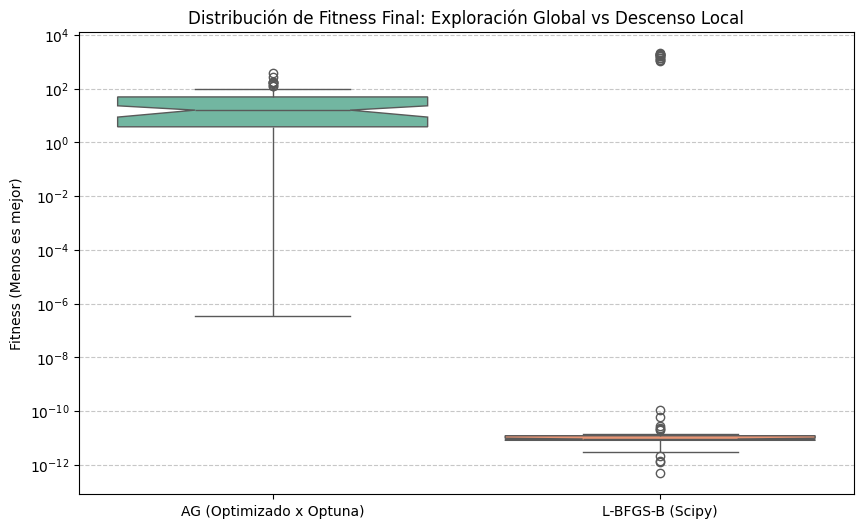


ESTADÍSTICAS FINALES (N=100)
AG -> Media: 38.040726 | Mediana: 15.841246 | Desv. Std: 59.063355
Scipy -> Media: 208.350776 | Mediana: 0.000000 | Desv. Std: 551.367743


In [127]:
# --- Boxplot de Comparación ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=[results_ga, results_scipy], palette="Set2", notch=True)
plt.xticks([0, 1], ['AG (Optimizado x Optuna)', 'L-BFGS-B (Scipy)'])
plt.title('Distribución de Fitness Final: Exploración Global vs Descenso Local')
plt.ylabel('Fitness (Menos es mejor)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Si hay mucha diferencia de escala, activamos escala logarítmica
if np.max(results_ga) / (np.min(results_ga) + 1e-9) > 100:
    plt.yscale('log')

plt.show()

# --- Resumen Estadístico ---
print(f"\n{'='*40}")
print(f"ESTADÍSTICAS FINALES (N={N_RUNS})")
print(f"{'='*40}")
print(f"AG -> Media: {np.mean(results_ga):.6f} | Mediana: {np.median(results_ga):.6f} | Desv. Std: {np.std(results_ga):.6f}")
print(f"Scipy -> Media: {np.mean(results_scipy):.6f} | Mediana: {np.median(results_scipy):.6f} | Desv. Std: {np.std(results_scipy):.6f}")

En comparacion con el algoritmo de gradiente (state of art), le va bastante bien, si vemos las medias, nuestro algoritmo le va bastante bien, lo que sucede, es que el sgd, en esta funcion (banana de Rosenbrock), tiene una precision muy alta, una vez que llego a la zona del minimo, funciona de manera excelente, pero tiene unos outliers muymuy altos.

## Ejercicio 2
- Implementación de PSO
- Comparación contra algoritmo genetico

### Implementación del PSO